# Pertemuan 11 - Unsupervised Learning: Clustering

**Nama:** Krisna Naufal Azhar Suhendar  
**NIM:** 240401070506  
**Kelas:** IF 604

Mata Kuliah: Data Science



##Import Library & Generate Dataset

Shape : (300, 4)


,pendapatan_tahunan,skor_belanja,usia,gender
0,32.980285,18.893886,64,P
1,33.886131,32.184239,21,P
2,28.595080,18.126904,29,L
3,39.475277,26.139478,62,L
4,27.183154,24.340480,19,L


       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


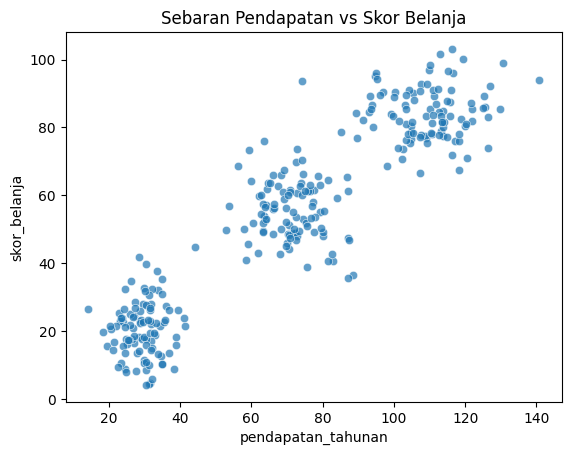

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis pelanggan
np.random.seed(42)

grp1 = np.random.normal([30, 20], [6, 8], (100, 2))
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))

data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(
    data,
    columns=['pendapatan_tahunan', 'skor_belanja']
)

df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print("Shape :", df.shape)
display(df.head())

print(df.describe().round(2))

sns.scatterplot(
    data=df,
    x='pendapatan_tahunan',
    y='skor_belanja',
    alpha=0.7
)

plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.show()

##Prepocessing

In [5]:
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Rata-rata setelah scaling :", X_scaled.mean(axis=0).round(3))
print("Standar deviasi :", X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling : [-0.  0.]
Standar deviasi : [1. 1.]


##Elbow Method

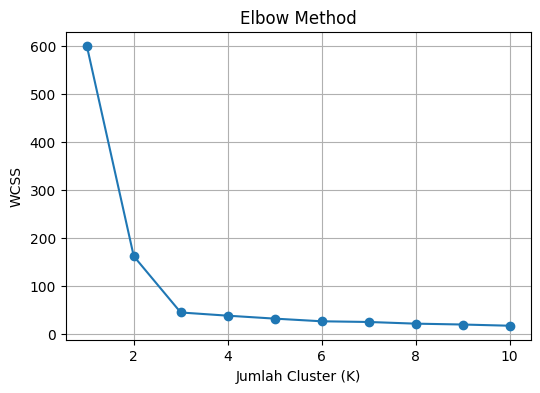

In [6]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        init='k-means++'
    )

    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

##K-Means

In [7]:
from sklearn.metrics import silhouette_score

model = KMeans(
    n_clusters=3,
    random_state=42,
    init='k-means++'
)

model.fit(X_scaled)

df['cluster'] = model.labels_

print("WCSS :", round(model.inertia_,3))
print("Silhouette Score :", round(silhouette_score(X_scaled, model.labels_),3))

display(
    df.groupby('cluster')[['pendapatan_tahunan','skor_belanja']].mean().round(2)
)

WCSS : 44.556
Silhouette Score : 0.695


,pendapatan_tahunan,skor_belanja
cluster,,
0,70.99,55.05
1,29.31,20.27
2,109.20,84.08


##Visualisasi Cluster

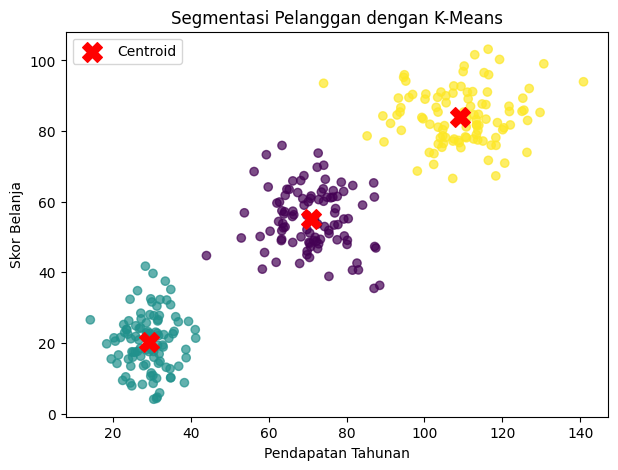

In [8]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7,5))

plt.scatter(
    df['pendapatan_tahunan'],
    df['skor_belanja'],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.7
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    marker='X',
    s=200,
    label='Centroid'
)

plt.xlabel("Pendapatan Tahunan")
plt.ylabel("Skor Belanja")
plt.title("Segmentasi Pelanggan dengan K-Means")

plt.legend()

plt.show()

##Hierarchical Clustering

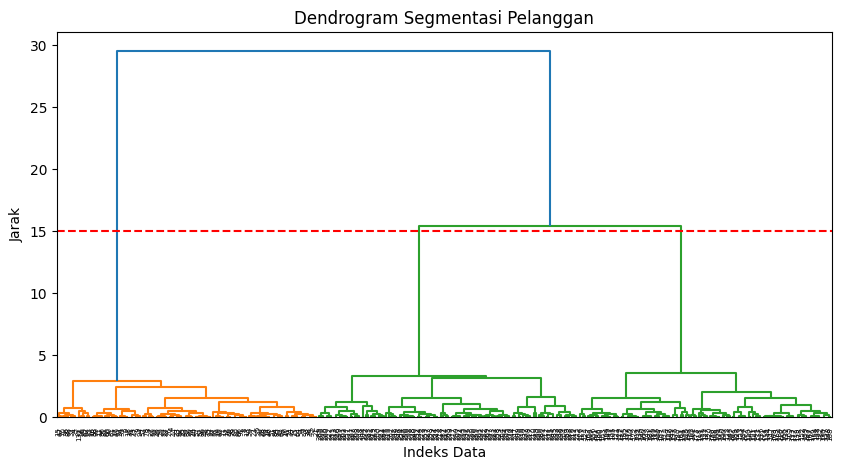

In [9]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))

dendrogram(Z)

plt.axhline(y=15, color='red', linestyle='--')

plt.title("Dendrogram Segmentasi Pelanggan")
plt.xlabel("Indeks Data")
plt.ylabel("Jarak")

plt.show()

##Kesimpulan

Pada praktikum ini dipelajari proses segmentasi pelanggan menggunakan metode K-Means dan Hierarchical Clustering. Metode Elbow menunjukkan jumlah cluster optimal adalah **3**, sesuai dengan karakteristik dataset sintetis. Hasil clustering membagi pelanggan menjadi tiga segmen utama, yaitu pelanggan hemat, pelanggan menengah, dan pelanggan premium. Hierarchical Clustering juga menghasilkan pola yang konsisten dengan K-Means sehingga kedua metode dapat digunakan untuk membantu proses segmentasi pelanggan berdasarkan karakteristik yang dimiliki.